### Basic ChatBot (Graph API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END

from langgraph.graph.message import add_messages # reducers - to append the message 


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = init_chat_model("groq:llama-3.3-70b-versatile")


In [4]:
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x109af9e80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x109afaba0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
"Node functionality"
def chatBot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [6]:
# Building Graph

graph_builder = StateGraph(State)

# adding nodes to the graph
graph_builder.add_node("llmchatBot",chatBot)

# adding edges to the graph
graph_builder.add_edge(START, "llmchatBot")
graph_builder.add_edge("llmchatBot", END)

# compile the graph
graph = graph_builder.compile()

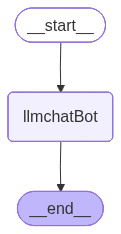

In [7]:
# visulazing the graph

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [8]:
response = graph.invoke({"messages": ["Hello, how are you?"]})

In [9]:
response["messages"] 
response["messages"][-1] # last message in the list of messages
response["messages"][-1].content

"Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?"

In [10]:
for event in graph.stream({"messages": ["Can you tell me about today's news in India?"]}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm a large language model, I don't have have access to real-time news or current events. My training data is cut off in 2023, so I won't be able to provide you with the latest news in India or anywhere else. However, I can suggest some reputable news sources that you can check for the latest updates:

1. The Times of India: A leading English-language newspaper in India that covers national and international news.
2. Hindustan Times: Another prominent English-language newspaper in India that covers a wide range of topics, including politics, business, and sports.
3. India Today: A popular news magazine that covers current events, politics, and social issues.
4. NDTV: A 24-hour news channel that provides live updates on national and international news.
5. The Hindu: A widely respected English-language newspaper that covers news, opinion, and analysis on a range of topics.

You can visit the websites of these news sources or download their mobile apps to stay up-to-date with the latest n

### chatbot with tool

In [11]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [12]:
## custom function 

def multiply(a:int,b:int)-> int:
    """Multiply a and b 
     
    Args:
        a (int) : first int
        b (int) : second int 

    Returns:
        int : output int
    """
    return a*b

In [13]:
tools = [tool,multiply]

In [14]:
llm_with_tool = llm.bind_tools(tools)

In [15]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x109af9e80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x109afaba0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need 

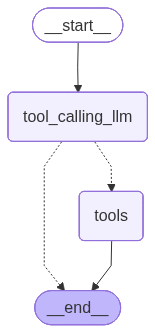

In [16]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
response=graph.invoke({"messages":"what is the recent apple news"})

In [18]:
response

{'messages': [HumanMessage(content='what is the recent apple news', additional_kwargs={}, response_metadata={}, id='8a129970-445e-4b67-b195-2dbe8020f1ad'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'kvvmacjpw', 'function': {'arguments': '{"query":"recent apple news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1751, 'total_tokens': 1782, 'completion_time': 0.096269487, 'completion_tokens_details': None, 'prompt_time': 0.158707181, 'prompt_tokens_details': None, 'queue_time': 0.051817916, 'total_time': 0.254976668}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1cea-b107-7512-b695-38f3c0c2eb03-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent apple news', 'time_range': 'day', 't

In [19]:
response['messages'][-1].content

'{"query": "recent apple news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.macrumors.com/2026/06/30/apple-watch-redesign-coming-next-year/", "title": "Report: Apple Watch Redesign Coming Next Year With New Band System - MacRumors", "score": 0.63397753, "published_date": "Tue, 30 Jun 2026 15:45:44 GMT", "content": "# Report: Apple Watch Redesign Coming Next Year With New Band System. A \\"major overhaul\\" of the Apple Watch\'s design is due to arrive next year with a new system for connecting bands, according to a known Weibo leaker. In a set of recent posts, the leaker known as \\"Instant Digital\\" linked the new claim to older rumors about an \\"Apple Watch X\\" model, which was said to introduce a fresh design and break compatibility with the existing watch band system. The leaker went on to advise that anyone planning to buy a new Apple Watch in 2027 should hold off on buying extra bands in the meantime, given that a redesigned case

In [20]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent apple news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (kvvmacjpw)
 Call ID: kvvmacjpw
  Args:
    query: recent apple news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent apple news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.macrumors.com/2026/06/30/apple-watch-redesign-coming-next-year/", "title": "Report: Apple Watch Redesign Coming Next Year With New Band System - MacRumors", "score": 0.63397753, "published_date": "Tue, 30 Jun 2026 15:45:44 GMT", "content": "# Report: Apple Watch Redesign Coming Next Year With New Band System. A \"major overhaul\" of the Apple Watch's design is due to arrive next year with a new system for connecting bands, according to a known W

In [21]:
response=graph.invoke({"messages":"what is 3 multiplied by 6"})

In [22]:
response

{'messages': [HumanMessage(content='what is 3 multiplied by 6', additional_kwargs={}, response_metadata={}, id='2fe558e1-9de6-4c47-a91c-6571a03c4483'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'hm0g36f49', 'function': {'arguments': '{"a":3,"b":6}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1753, 'total_tokens': 1772, 'completion_time': 0.059973801, 'completion_tokens_details': None, 'prompt_time': 0.09011148, 'prompt_tokens_details': None, 'queue_time': 0.051008488, 'total_time': 0.150085281}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1cea-b885-7343-9acb-ecd8010181e1-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 6}, 'id': 'hm0g36f49', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1753

In [23]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 3 multiplied by 6
================================== Ai Message ==================================
Tool Calls:
  multiply (hm0g36f49)
 Call ID: hm0g36f49
  Args:
    a: 3
    b: 6
================================= Tool Message =================================
Name: multiply

18


In [24]:
response=graph.invoke({"messages":"what is 3 multiplied by 6 and then 67"})

In [25]:
response

{'messages': [HumanMessage(content='what is 3 multiplied by 6 and then 67', additional_kwargs={}, response_metadata={}, id='e217b73d-9a4f-48e6-bc4c-842df7417793'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wwqymghvb', 'function': {'arguments': '{"a":3,"b":6}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 1757, 'total_tokens': 1794, 'completion_time': 0.092048172, 'completion_tokens_details': None, 'prompt_time': 0.130543197, 'prompt_tokens_details': None, 'queue_time': 0.163207151, 'total_time': 0.222591369}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1cea-b9ad-74e1-8f7a-d6d9b3537aca-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 6}, 'id': 'wwqymghvb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_

In [26]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 3 multiplied by 6 and then 67
================================== Ai Message ==================================
Tool Calls:
  multiply (wwqymghvb)
 Call ID: wwqymghvb
  Args:
    a: 3
    b: 6
================================= Tool Message =================================
Name: multiply

18


### ReAct Agent Architecture

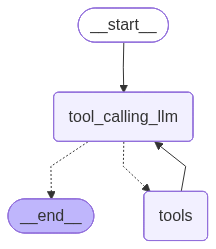

In [27]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (43fgdxv22)
 Call ID: 43fgdxv22
  Args:
    query: recent ai news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.mediapost.com/publications/article/416212/amazon-doubled-ai-referred-purchases-clickstream.html", "title": "Amazon Doubled AI-Referred Purchases, Clickstream Data Shows 07/01/2026 - MediaPost", "score": 0.68697983, "published_date": "Tue, 30 Jun 2026 17:42:48 GMT", "content": "*   Become A MediaPost Member Subscribe to your choice of industry specific newsletters, save $100 on conferences, search member d

### Adding Memory in Agentic Graph

In [29]:
response = graph.invoke({"messages":"hello i am ketan"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

hello i am ketan
================================== Ai Message ==================================

Hello Ketan, it's nice to meet you. Is there something I can help you with or would you like to chat?


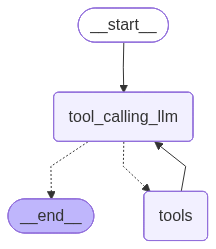

In [30]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

response = graph.invoke(
    {"messages": "Hi i am ketan"},
    config=config
)

response

{'messages': [HumanMessage(content='Hi i am ketan', additional_kwargs={}, response_metadata={}, id='0ddffe73-2efb-4f3b-b85f-5f9d76f904b6'),
  AIMessage(content="Hello Ketan! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1750, 'total_tokens': 1777, 'completion_time': 0.084838704, 'completion_tokens_details': None, 'prompt_time': 0.092779068, 'prompt_tokens_details': None, 'queue_time': 0.05085598, 'total_time': 0.177617772}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1cea-e0d7-7090-964c-a89f6da1b0ed-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 27, 'total_tokens': 1777})]}

In [32]:
response['messages'][-1].content

"Hello Ketan! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [33]:
response = graph.invoke({"messages":"Hey what is my name"},config=config)
print(response['messages'][-1].content)

Your name is Ketan.


### Streaming 

In [34]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [35]:
def superBot(state:State):
    return {'messages':[llm.invoke(state['messages'])]}

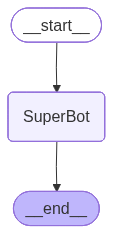

In [36]:
graph = StateGraph(State)

graph.add_node('SuperBot',superBot)

graph.add_edge(START,"SuperBot")
graph.add_edge('SuperBot',END)

builder = graph.compile(checkpointer=memory)

from IPython.display import Image,display
display(Image(builder.get_graph().draw_mermaid_png()))

In [37]:
conifg = {"configurable":{"thread_id":"1"}}

builder.invoke({"messages":"Hi, my name is ketan and i like football"},config)

{'messages': [HumanMessage(content='Hi, my name is ketan and i like football', additional_kwargs={}, response_metadata={}, id='34e23304-4bc8-4711-921c-63e55fac6c45'),
  AIMessage(content="Nice to meet you, Ketan. Football is an exciting sport, isn't it? Which team or player is your favorite? Do you play football yourself or just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 46, 'total_tokens': 84, 'completion_time': 0.101958594, 'completion_tokens_details': None, 'prompt_time': 0.004187394, 'prompt_tokens_details': None, 'queue_time': 0.162345336, 'total_time': 0.106145988}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1ceb-2522-7eb2-a8ba-68c66a61d2d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 38, 'total_tokens': 8

# Streaming in LangGraph

LangGraph provides two methods for streaming graph execution results:

- **`.stream()`** – Synchronous streaming
- **`.astream()`** – Asynchronous streaming

## Streaming Modes

### 1. `values`

Streams the **entire graph state** after each node execution.

- Returns the complete state at every step.
- Useful for monitoring the full state throughout the workflow.

```python
graph.stream(
    {"messages": "Hello"},
    stream_mode="values"
)
```

---

### 2. `updates`

Streams **only the changes (updates)** made to the graph state after each node execution.

- Returns only the state modifications.
- More efficient when you only need to track what changed.

```python
graph.stream(
    {"messages": "Hello"},
    stream_mode="updates"
)
```

In [45]:
config = {"configurable":{"thread_id":"3"}}

for chunk in builder.stream({'messages':"hi, my name is ketan and i like skateboarding"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Ketan, that's awesome! Skateboarding is an exciting and challenging sport. What do you like most about skateboarding? Is it the thrill of learning new tricks, the speed, or the sense of community with other skaters?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 47, 'total_tokens': 96, 'completion_time': 0.152326283, 'completion_tokens_details': None, 'prompt_time': 0.002137961, 'prompt_tokens_details': None, 'queue_time': 0.161571158, 'total_time': 0.154464244}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1db4-22bf-7171-ba06-da81d7e9c3ef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 49, 'total_tokens': 96})]}}


In [46]:
for chunk in builder.stream({"messages":"hi, my name is ketan and i like skateboarding"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi, my name is ketan and i like skateboarding', additional_kwargs={}, response_metadata={}, id='67ca2223-bbb3-42e8-af4a-af9762d5bc41'), AIMessage(content="Hi Ketan, that's awesome! Skateboarding is an exciting and challenging sport. What do you like most about skateboarding? Is it the thrill of learning new tricks, the speed, or the sense of community with other skaters?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 47, 'total_tokens': 96, 'completion_time': 0.152326283, 'completion_tokens_details': None, 'prompt_time': 0.002137961, 'prompt_tokens_details': None, 'queue_time': 0.161571158, 'total_time': 0.154464244}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1db4-22bf-7171-ba06-da81d7e9c3ef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata

In [48]:
## creating a new thread

config = {"configurable":{"thread_id":"4"}}

for chunk in builder.stream({"messages":"Hi,my name is ketan and i like skateboarding"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,my name is ketan and i like skateboarding', additional_kwargs={}, response_metadata={}, id='7ddd389a-6ebb-418e-b5e1-eb55bbce0508')]}
{'messages': [HumanMessage(content='Hi,my name is ketan and i like skateboarding', additional_kwargs={}, response_metadata={}, id='7ddd389a-6ebb-418e-b5e1-eb55bbce0508'), AIMessage(content="What's up Ketan! That's awesome that you're into skateboarding! It's an amazing sport that requires skill, balance, and practice. What do you like most about skateboarding? Do you have a favorite trick or skate spot?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 47, 'total_tokens': 97, 'completion_time': 0.153321905, 'completion_tokens_details': None, 'prompt_time': 0.001447288, 'prompt_tokens_details': None, 'queue_time': 0.162607242, 'total_time': 0.154769193}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finis

In [49]:
for chunk in builder.stream({"messages":"hi , i also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,my name is ketan and i like skateboarding', additional_kwargs={}, response_metadata={}, id='7ddd389a-6ebb-418e-b5e1-eb55bbce0508'), AIMessage(content="What's up Ketan! That's awesome that you're into skateboarding! It's an amazing sport that requires skill, balance, and practice. What do you like most about skateboarding? Do you have a favorite trick or skate spot?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 47, 'total_tokens': 97, 'completion_time': 0.153321905, 'completion_tokens_details': None, 'prompt_time': 0.001447288, 'prompt_tokens_details': None, 'queue_time': 0.162607242, 'total_time': 0.154769193}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1db8-13fb-76e1-bb55-187a07c11f8f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'

In [53]:
config = {"configurable":{"thread_id":"5"}}

async for event in builder.astream_events({"messages":"hi , i also like football"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'hi , i also like football'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f1dbd-2df9-7a82-92dd-34664df5e77b', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='hi , i also like football', additional_kwargs={}, response_metadata={}, id='5ad0fe07-c911-4be4-9147-e8ed78e909c1'), AIMessage(content="That's great to hear that you like football. Which team or player is your favorite? Are you more into watching professional leagues like the English Premier League, La Liga, or the Champions League, or do you also enjoy playing the game yourself?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 41, 'total_tokens': 91, 'completion_time': 0.17571668, 'completion_tokens_details': None, 'prompt_time': 0.00124123, 'prompt_tokens_details': None, 'queue_time': 0.05513343, 'total_